In [1]:
# Plot regional mortality as a box plot

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from utils.utils import get_scenario_config

In [3]:
def load_regional_mortality_ensemble_members(model, scenario, config):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Regional_mortality_stats_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataset(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [4]:
def process_final_decade_for_boxplot(ds, var_prefix="M"):
    """
    Build boxplot stats dictionaries for each region using the final 10 years of data.
    Ensemble mean is used, but regions are preserved.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain variables: {prefix}_mean, {prefix}_median, {prefix}_25,
        {prefix}_75, {prefix}_lower95, {prefix}_upper95
        and coordinates 'year', 'ensemble', 'region'.
    var_prefix : str
        Prefix for variable names (default: "M").

    Returns
    -------
    stats_dict : dict
        Keys = region names, values = list with a single boxplot stats dict.
        This structure allows direct use with ax.bxp().
    regions : list
        List of region names (in the same order as stats_dict).
    """

    # collapse ensemble dimension
    ds_mean = ds.mean(dim="ensemble")

    # define final decade
    end_year = int(ds_mean.year.max())
    start_year = end_year - 9
    sub = ds_mean.sel(year=slice(start_year, end_year))

    # build stats for each region
    stats_dict = {}
    for region in sub.region.values:
        reg = sub.sel(region=region)

        stats_dict[region] = [{
            "med": float(reg[f"{var_prefix}_median"].mean()),
            "mean": float(reg[f"{var_prefix}_mean"].mean()),
            "q1": float(reg[f"{var_prefix}_25"].mean()),
            "q3": float(reg[f"{var_prefix}_75"].mean()),
            "whislo": float(reg[f"{var_prefix}_lower95"].mean()),
            "whishi": float(reg[f"{var_prefix}_upper95"].mean()),
            "fliers": []
        }]

    return stats_dict, list(stats_dict.keys())

In [5]:
def plot_regional_mortality(ds, model, scenario, years, log=True):
    # === Path config ===
    SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Regional"

    stats_dict, regions = process_final_decade_for_boxplot(ds)

    # Calculate end of scenario mean (10 years)
    end_idx = ds.sizes["year"]
    # Select the last 10 years
    ds_last10 = ds.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = ds_last10.year[0].item()
    end_time = ds_last10.year[-1].item()

    dates = f"{start_time}-{end_time}"

    # Sort by mean values (descending order)
    region_means = {r: float(stats_dict[r][0]['mean']) for r in regions}
    sorted_regions = sorted(regions, key=lambda r: region_means[r], reverse=True)

    # Build ordered box_data list (bxp expects a dict per box)
    box_data = []
    for r in sorted_regions:
        st = dict(stats_dict[r][0])  # copy so we don't mutate original
        st['label'] = r  # optional, helpful for debugging
        box_data.append(st)

    positions = np.arange(len(box_data))

    # Horizontal point plot with error bars and log x-axis
    fig, ax = plt.subplots(figsize=(8, 10))

    median_colour = "darkred"
    mean_colour = "black"

    bp = ax.bxp(
        box_data,
        vert=False,
        positions=positions,
        widths=0.6,
        showmeans=True,
        meanline=True,  # mean drawn as a line; set False to use marker
        patch_artist=True,
        medianprops=dict(color=median_colour, linewidth=1),
        meanprops=dict(color=mean_colour, linewidth=1, linestyle="--"),
    )

    # style boxes, whiskers and caps
    for box in bp["boxes"]:
        box.set(facecolor="lightgray", alpha=0.6)

    for whisker in bp["whiskers"]:
        whisker.set(color="black", linestyle="-")

    for cap in bp["caps"]:
        cap.set(color="black")

    plt.xlabel("Mortality (mean)")
    plt.ylabel("Region")
    plt.title(f"Mortality by Region with 95% CI\n {model} {scenario} {dates}")
    if log is True:
        plt.xscale('log')  # Logarithmic x-axis
        ticks = [0.001, 0.1, 10, 1000, 100000]
        plt.gca().set_xticks(ticks, ticks)
        out_file = f"Mortality_region_log_{model}_{scenario}_{dates}.png"
    else:
        out_file = f"Mortality_region_{model}_{scenario}_{dates}.png"
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    handles = [
        Patch(facecolor="lightgray", alpha=0.6, label="95% CI (box + whiskers)"),
        Line2D([0], [0], color=median_colour, lw=2, label="Median"),
        Line2D([0], [0], color=mean_colour, lw=2, linestyle="--", label="Mean"),
    ]
    ax.legend(handles=handles, loc="best")
    plt.tight_layout()

    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)

    return

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


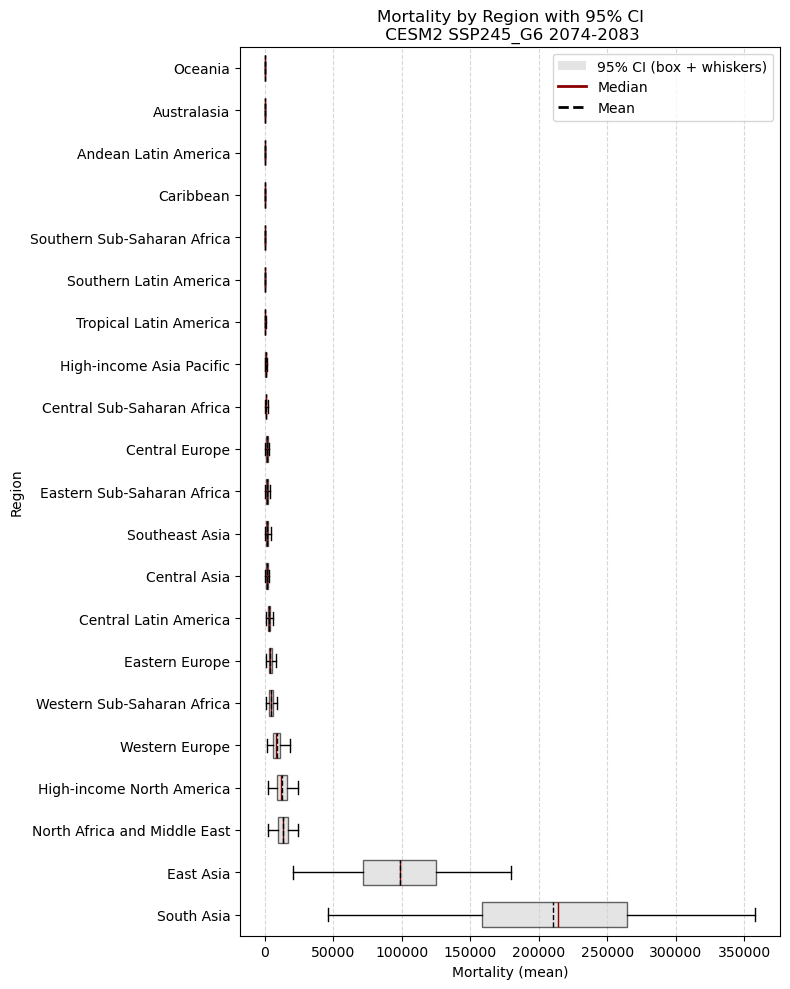

In [7]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Global/"

model = "CESM2"
scenario = "SSP245_G6"

config = get_scenario_config(model, scenario)
years = config["years"]

ds = load_regional_mortality_ensemble_members(model, scenario, config)

plot_regional_mortality(ds, model, scenario, years, log=False)

In [8]:
def plot_regional_mortality_diff(ds1, ds2, model, scenario, years, log=False):
    """
    Plot regional mortality differences (ds1 - ds2) as horizontal boxplots.
    Colours:
        - Red if IQR > 0
        - Blue if IQR < 0
        - Grey if IQR crosses zero
    """
    SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Regional"

    # Take difference
    ds = ds1 - ds2

    # Process into boxplot-ready stats
    stats_dict, regions = process_final_decade_for_boxplot(ds)

    # Select final 10 years
    end_idx = ds.sizes["year"]
    ds_last10 = ds.isel(year=slice(end_idx - 10, end_idx))
    start_time = ds_last10.year[0].item()
    end_time = ds_last10.year[-1].item()
    dates = f"{start_time}-{end_time}"

    # Sort by mean values
    region_means = {r: float(stats_dict[r][0]['mean']) for r in regions}
    sorted_regions = sorted(regions, key=lambda r: region_means[r], reverse=True)

    # Build box_data for plotting
    box_data = []
    for r in sorted_regions:
        st = dict(stats_dict[r][0])
        st["label"] = r
        box_data.append(st)

    positions = np.arange(len(box_data))

    fig, ax = plt.subplots(figsize=(8, 10))

    median_colour = "darkred"
    mean_colour = "black"

    bp = ax.bxp(
        box_data,
        vert=False,
        positions=positions,
        widths=0.6,
        showmeans=True,
        meanline=True,
        patch_artist=True,
        medianprops=dict(color=median_colour, linewidth=1),
        meanprops=dict(color=mean_colour, linewidth=1, linestyle="--"),
    )

    # === Apply conditional coloring based on IQR ===
    for box, st in zip(bp["boxes"], box_data):
        q1, q3 = st["q1"], st["q3"]
        if q1 > 0 and q3 > 0:        # entirely positive
            box.set(facecolor="red", alpha=0.6)
        elif q1 < 0 and q3 < 0:      # entirely negative
            box.set(facecolor="blue", alpha=0.6)
        else:                        # crosses zero
            box.set(facecolor="lightgray", alpha=0.6)

    # Style whiskers/caps
    for whisker in bp["whiskers"]:
        whisker.set(color="black", linestyle="-")
    for cap in bp["caps"]:
        cap.set(color="black")

    ax.set_xlabel("Mortality difference (mean)")
    ax.set_ylabel("Region")
    ax.set_title(f"Regional Mortality Difference (final decade)\n{model} {scenario} {dates}")

    if log is True:
        ax.set_xscale("log")
        out_file = f"MortalityDiff_region_log_{model}_{scenario}_{dates}.png"
    else:
        out_file = f"MortalityDiff_region_{model}_{scenario}_{dates}.png"

    ax.grid(axis="x", linestyle="--", alpha=0.5)

    handles = [
        Patch(facecolor="red", alpha=0.6, label="IQR > 0 (increase)"),
        Patch(facecolor="blue", alpha=0.6, label="IQR < 0 (decrease)"),
        Patch(facecolor="lightgray", alpha=0.6, label="IQR crosses zero"),
        Line2D([0], [0], color=median_colour, lw=2, label="Median"),
        Line2D([0], [0], color=mean_colour, lw=2, linestyle="--", label="Mean"),
    ]
    ax.legend(handles=handles, loc="best")

    plt.tight_layout()
    out_path = os.path.join(SAVE_DIR, out_file)
    #plt.savefig(out_path)

    return

In [12]:
def plot_regional_mortality_diff(ds1, ds2, model, scenario, years, symlog=True):
    """
    Plot regional mortality differences (ds1 - ds2) as horizontal boxplots.

    Colours:
        - Red if IQR > 0
        - Blue if IQR < 0
        - Grey if IQR crosses zero

    Parameters
    ----------
    ds1, ds2 : xarray.Dataset
        Input datasets with summary stats (mean, median, q1, q3, etc).
    model : str
        Model name for title/filename.
    scenario : str
        Scenario name for title/filename.
    years : unused here but included for consistency.
    symlog : bool, default=True
        Use symmetric log scale on x-axis (handles + and - values).
    """
    SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Regional"

    # Take difference
    ds = ds1 - ds2

    # Process into boxplot-ready stats
    stats_dict, regions = process_final_decade_for_boxplot(ds)

    # Select final 10 years
    end_idx = ds.sizes["year"]
    ds_last10 = ds.isel(year=slice(end_idx - 10, end_idx))
    start_time = ds_last10.year[0].item()
    end_time = ds_last10.year[-1].item()
    dates = f"{start_time}-{end_time}"

    # Sort by mean values
    region_means = {r: float(stats_dict[r][0]['mean']) for r in regions}
    sorted_regions = sorted(regions, key=lambda r: region_means[r], reverse=True)

    # Build box_data for plotting
    box_data = []
    for r in sorted_regions:
        st = dict(stats_dict[r][0])
        st["label"] = r
        box_data.append(st)

    positions = np.arange(len(box_data))

    fig, ax = plt.subplots(figsize=(8, 10))

    median_colour = "darkred"
    mean_colour = "black"

    bp = ax.bxp(
        box_data,
        vert=False,
        positions=positions,
        widths=0.6,
        showmeans=True,
        meanline=True,
        patch_artist=True,
        medianprops=dict(color=median_colour, linewidth=1),
        meanprops=dict(color=mean_colour, linewidth=1, linestyle="--"),
    )

    # === Apply conditional coloring based on IQR ===
    for box, st in zip(bp["boxes"], box_data):
        q1, q3 = st["q1"], st["q3"]
        if q1 > 0 and q3 > 0:        # entirely positive
            box.set(facecolor="red", alpha=0.6)
        elif q1 < 0 and q3 < 0:      # entirely negative
            box.set(facecolor="blue", alpha=0.6)
        else:                        # crosses zero
            box.set(facecolor="lightgray", alpha=0.6)

    # Style whiskers/caps
    for whisker in bp["whiskers"]:
        whisker.set(color="black", linestyle="-")
    for cap in bp["caps"]:
        cap.set(color="black")

    ax.set_xlabel("Mortality difference (mean)")
    ax.set_ylabel("Region")
    ax.set_title(f"Regional Mortality Difference (final decade)\n{model} {scenario} {dates}")

    if symlog:
        ax.set_xscale("symlog", linthresh=1e2)  # tweak linthresh as needed
        out_file = f"MortalityDiff_region_symlog_{model}_{scenario}_{dates}.png"
    else:
        out_file = f"MortalityDiff_region_linear_{model}_{scenario}_{dates}.png"

    ax.grid(axis="x", linestyle="--", alpha=0.5)

    handles = [
        Patch(facecolor="red", alpha=0.6, label="IQR > 0 (increase)"),
        Patch(facecolor="blue", alpha=0.6, label="IQR < 0 (decrease)"),
        Patch(facecolor="lightgray", alpha=0.6, label="IQR crosses zero"),
        Line2D([0], [0], color=median_colour, lw=2, label="Median"),
        Line2D([0], [0], color=mean_colour, lw=2, linestyle="--", label="Mean"),
    ]
    ax.legend(handles=handles, loc="best")

    plt.tight_layout()
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)

    return

In [9]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Global/"

model = "CESM2"
scenario = ["G6-1.5K", "SSP245_G6"]
scenario_name = f"{scenario[0]} - {scenario[1]}"  # Check this is the way round you want it

config1 = get_scenario_config(model, scenario[0])
config2 = get_scenario_config(model, scenario[1])

da1 = load_regional_mortality_ensemble_members(model, scenario[0], config1)
da2 = load_regional_mortality_ensemble_members(model, scenario[1], config2)


Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


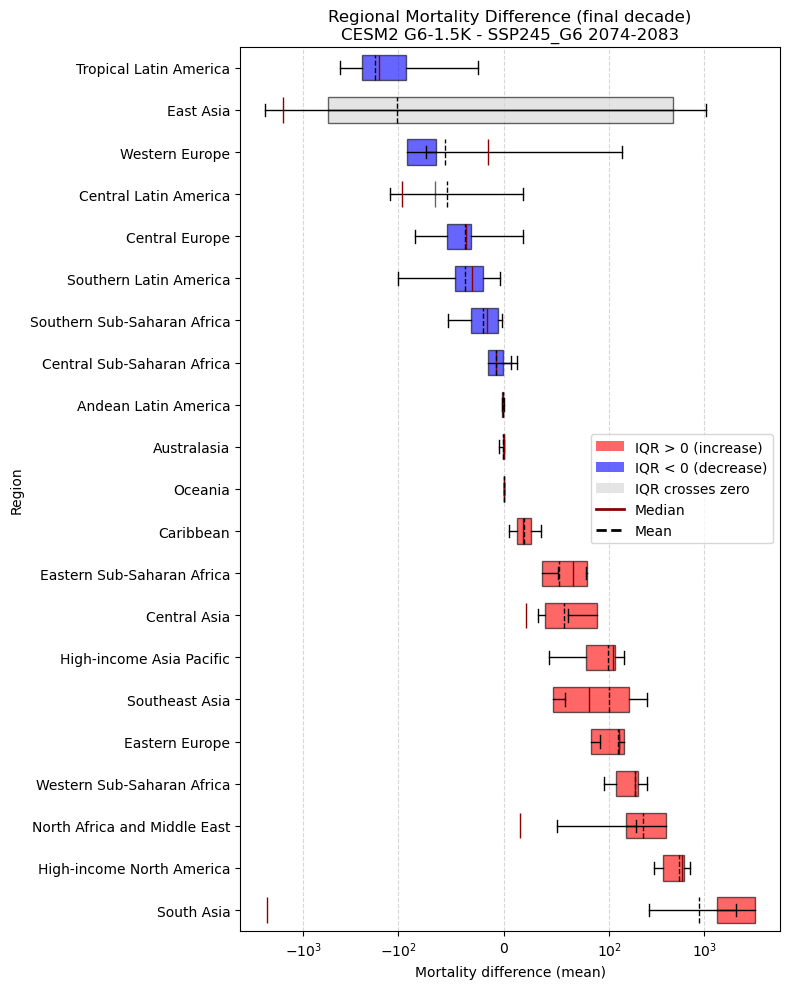

In [13]:
plot_regional_mortality_diff(da1, da2, model, scenario_name, years, True)

In [14]:
da = da1 - da2

In [36]:
def create_stats(da):
    median = da["M_median"]
    mean = da["M_mean"]
    q1 = da["M_25"]
    q3 = da["M_75"]
    whislo = da["M_lower95"]
    whishi = da["M_upper95"]

    stats_dict = [{
        "med": float(median),
        "mean": float(mean),
        "q1": float(q1),
        "q3": float(q3),
        "whislo": float(whislo),
        "whishi": float(whishi),
        "fliers": []
    }]
    return stats_dict

In [41]:
da1_dec = da1.sel(year=slice("2073", "2084")).mean(dim=("year", "ensemble"))
stats_da1 = create_stats(da1_dec.isel(region=1))

In [42]:
stats_da1

[{'med': 0.13503111898899078,
  'mean': 0.539919376373291,
  'q1': 0.012410552240908146,
  'q3': 0.794744074344635,
  'whislo': 0.0003996542654931545,
  'whishi': 2.8246476650238037,
  'fliers': []}]

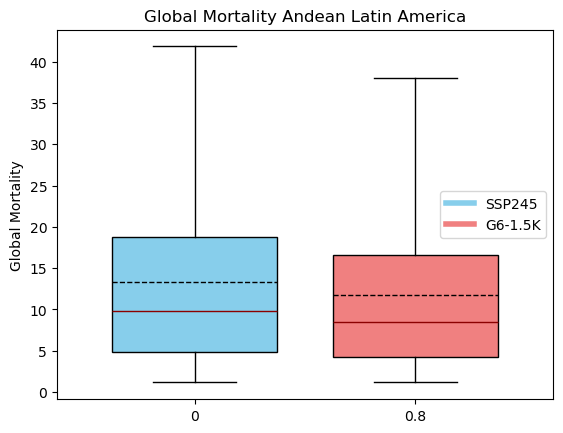

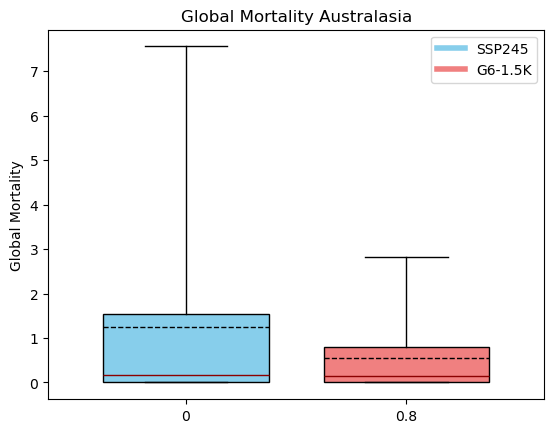

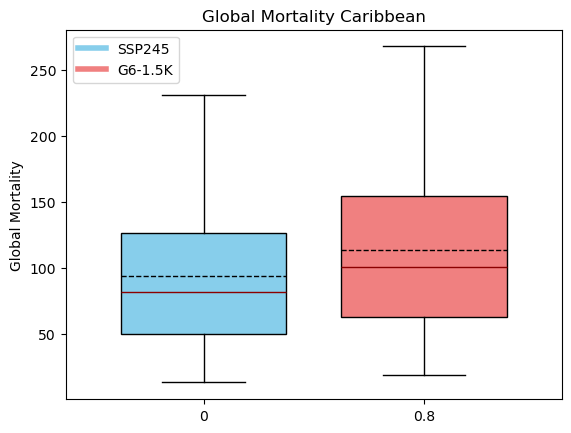

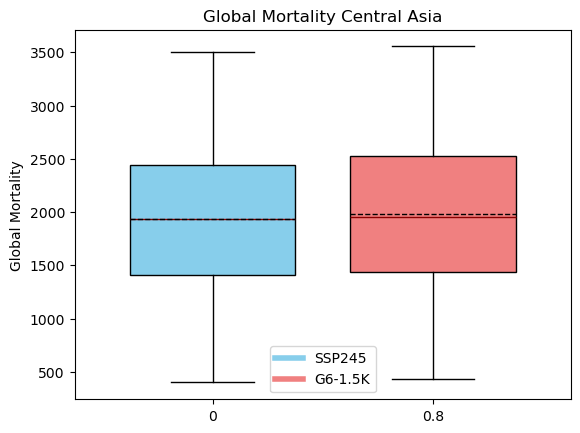

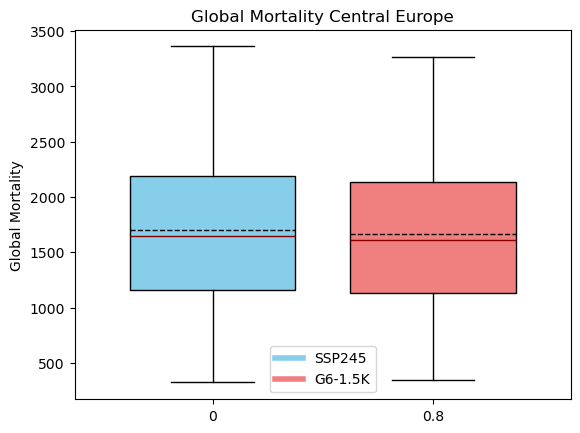

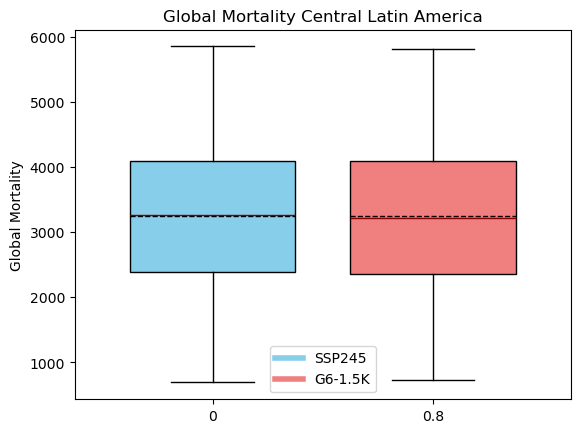

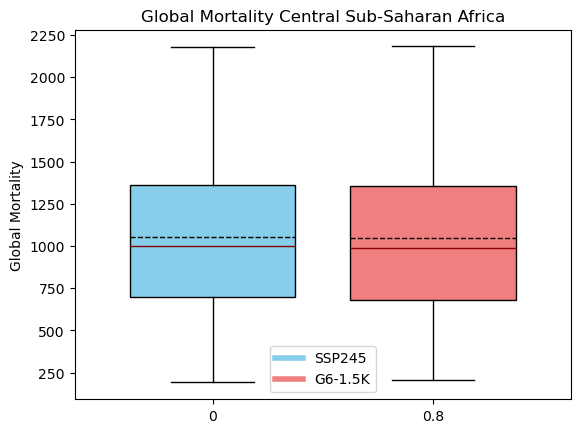

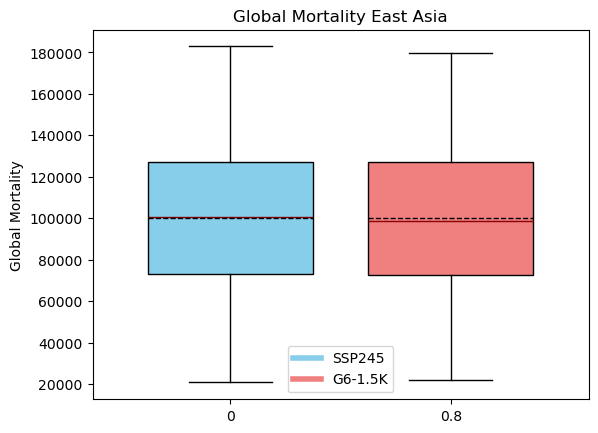

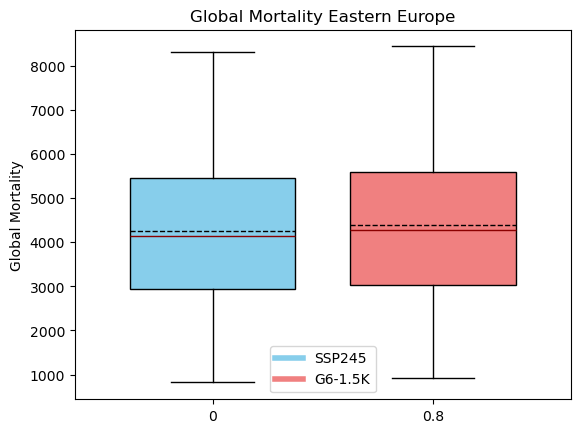

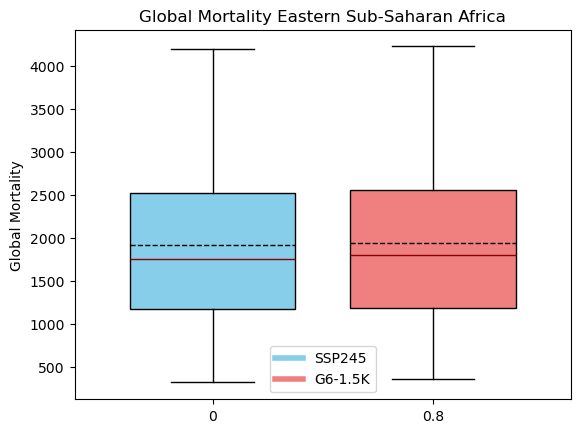

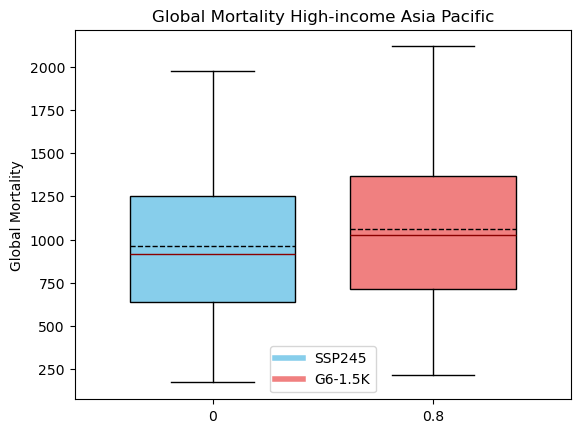

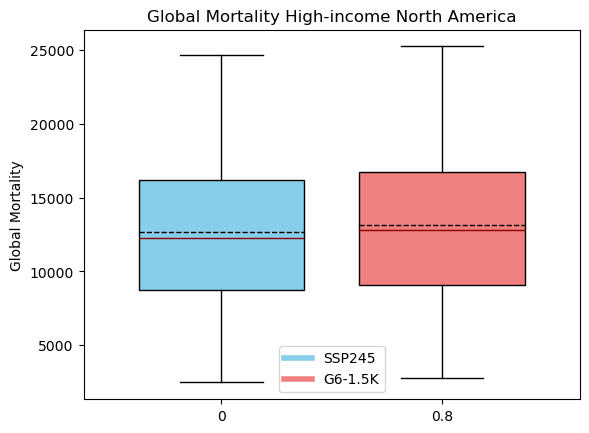

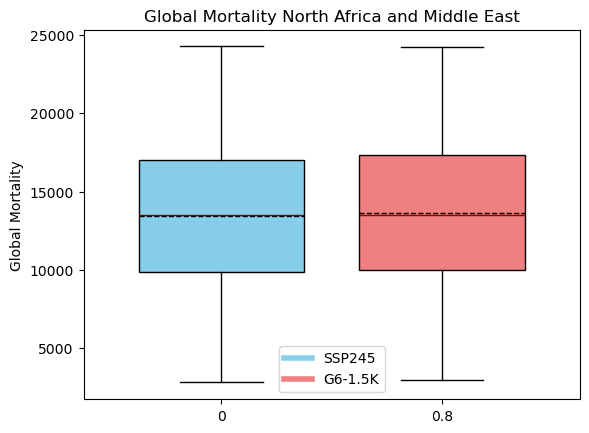

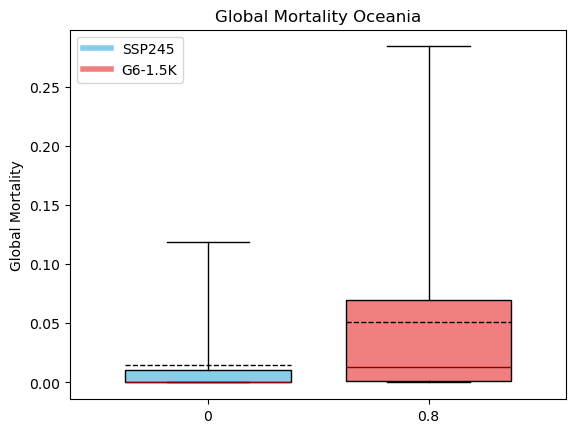

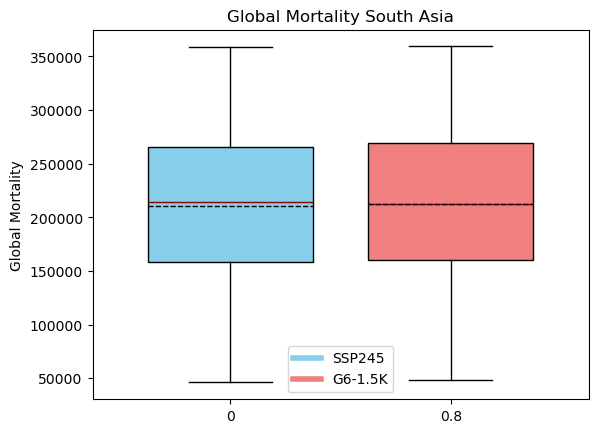

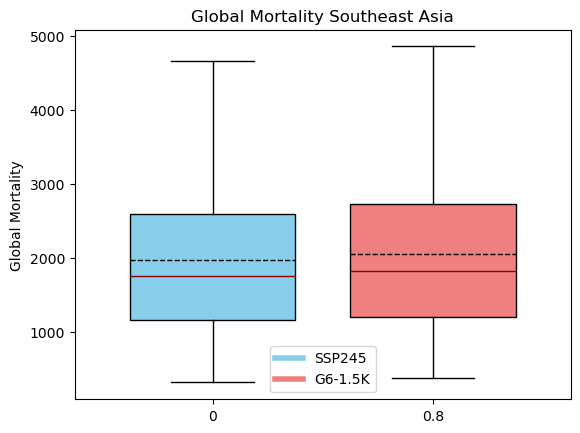

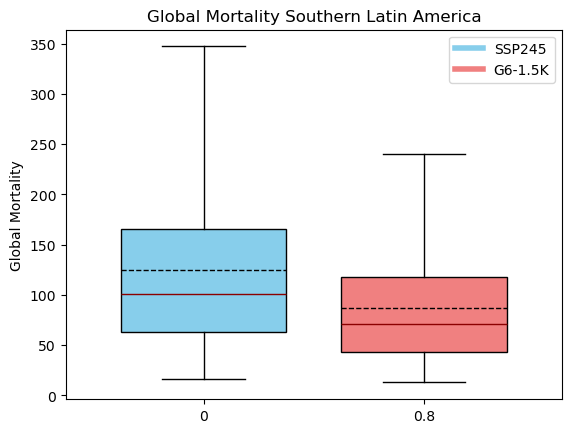

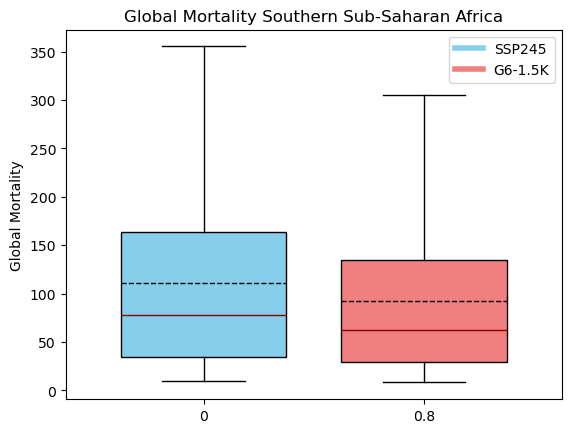

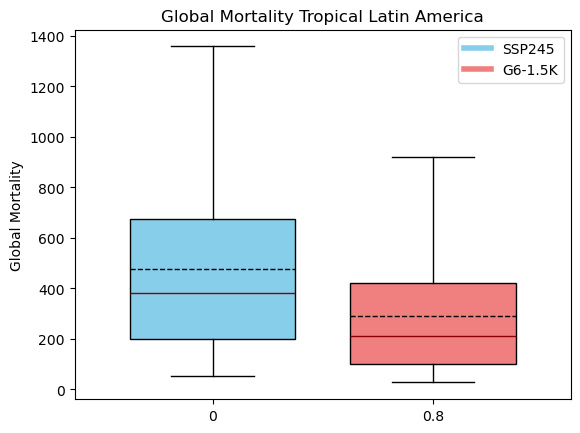

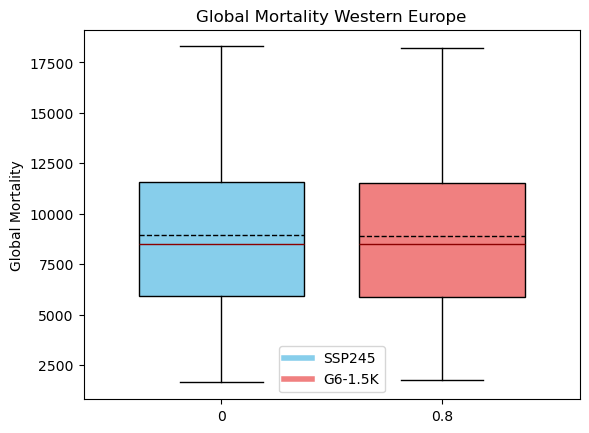

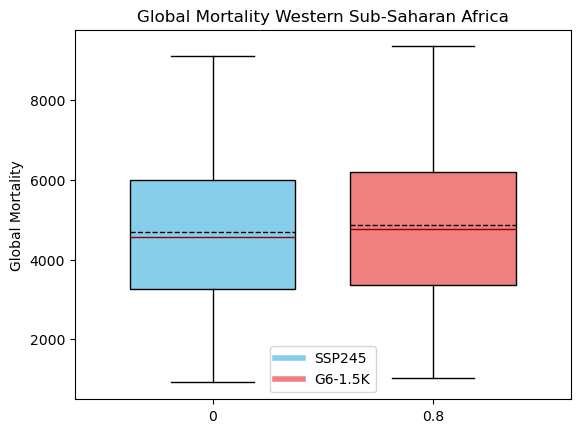

In [44]:
da1_dec = da1.sel(year=slice("2073", "2084")).mean(dim=("year", "ensemble"))
da2_dec = da2.sel(year=slice("2073", "2084")).mean(dim=("year", "ensemble"))

for region in da.region:
    stats_B = create_stats(da1_dec.sel(region=region))
    stats_A = create_stats(da2_dec.sel(region=region))

    fig, ax = plt.subplots()

    # x positions for each group
    x_A = np.arange(1)  # space out decades
    x_B = x_A + 0.8  # offset for dataset B

    # Plot dataset A
    ax.bxp(
        stats_A,
        positions=x_A,
        widths=0.6,
        showmeans=True,
        meanline=True,
        patch_artist=True,
        boxprops=dict(facecolor="skyblue"),
        medianprops=dict(color="darkred", linewidth=1),  # median line
        meanprops=dict(color="black", linewidth=1, ls="--")  # mean line
    )

    # Plot dataset B
    ax.bxp(stats_B,
           positions=x_B,
           widths=0.6,
           showmeans=True,
           meanline=True,
           patch_artist=True,
           boxprops=dict(facecolor="lightcoral"),
           medianprops=dict(color="darkred", linewidth=1),  # median line
           meanprops=dict(color="black", linewidth=1, ls="--")  # mean line
    )

    ax.set_ylabel("Global Mortality")
    ax.legend([plt.Line2D([0], [0], color="skyblue", lw=4),
               plt.Line2D([0], [0], color="lightcoral", lw=4)],
              ["SSP245", "G6-1.5K"])

    plt.title(f"Global Mortality {region.data}")
    plt.show()

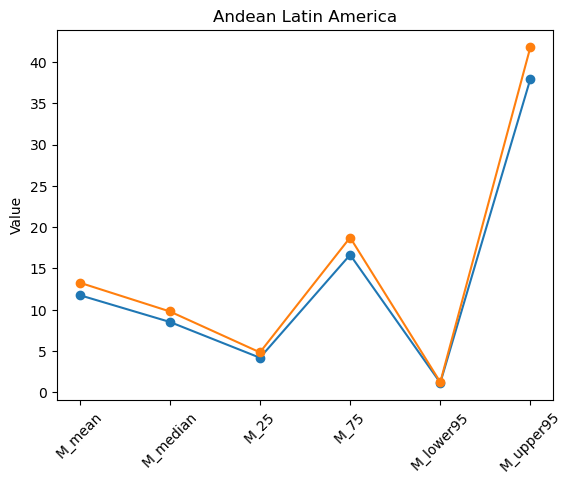

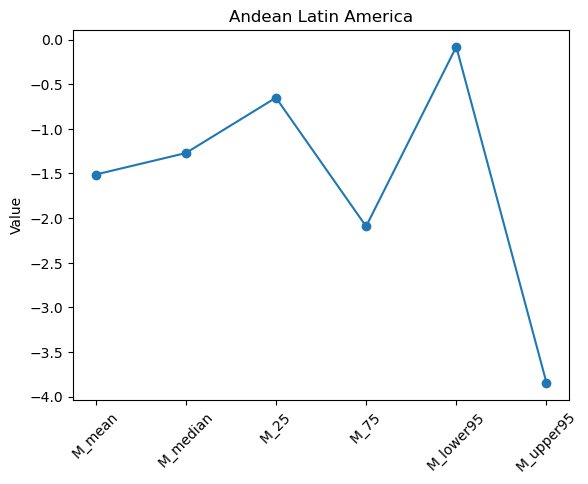

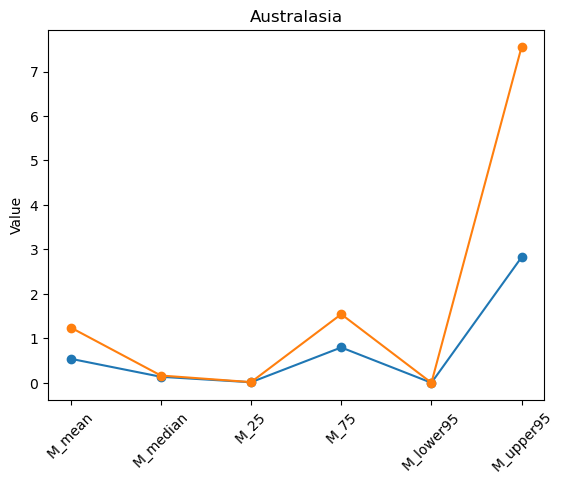

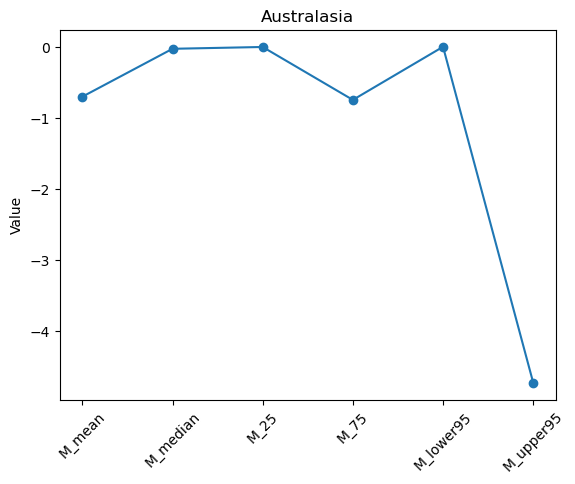

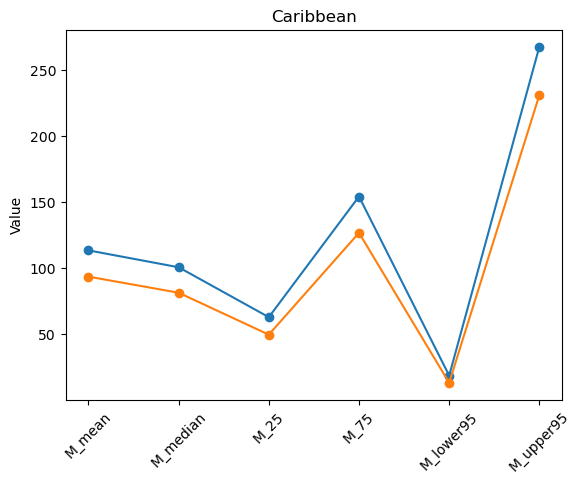

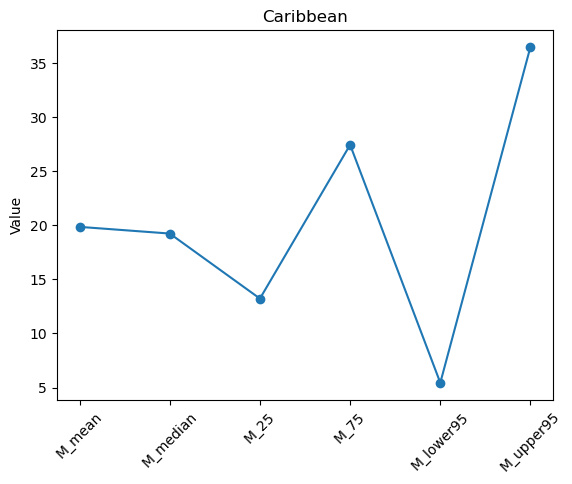

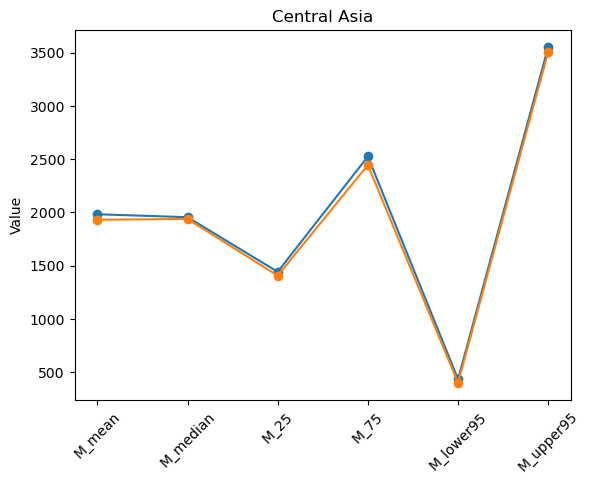

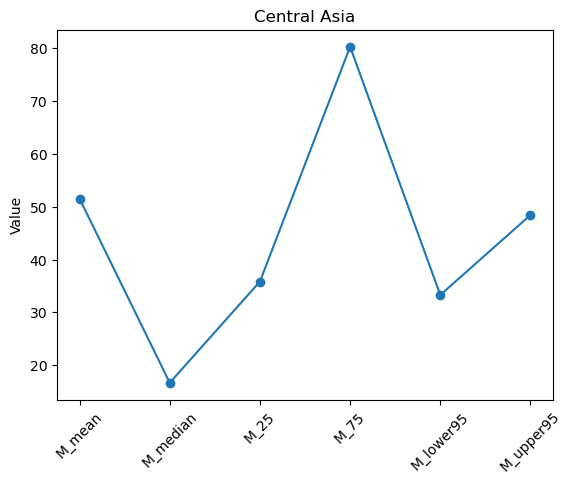

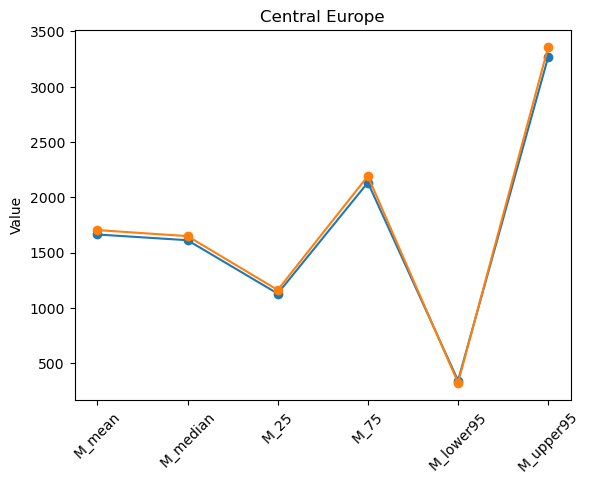

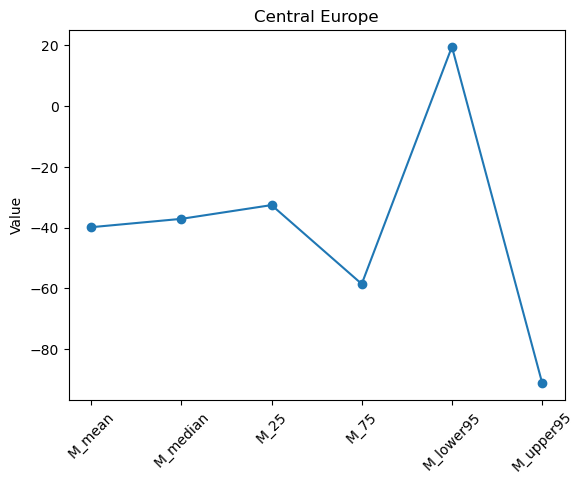

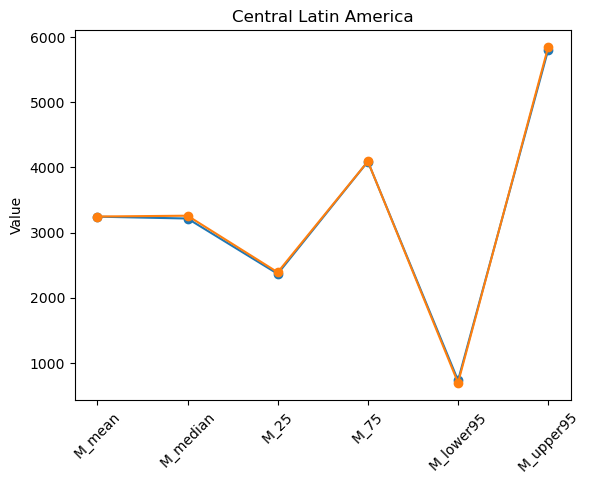

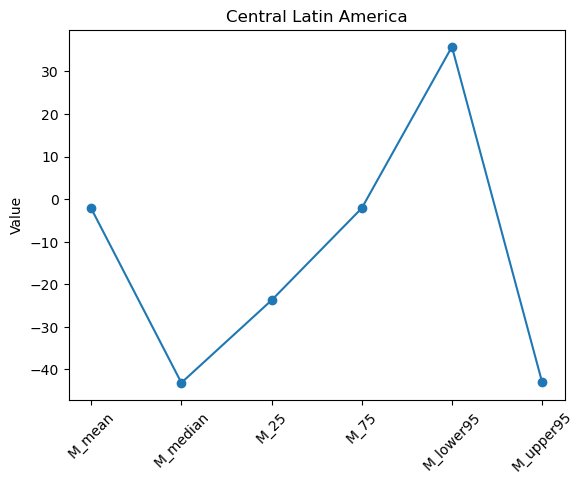

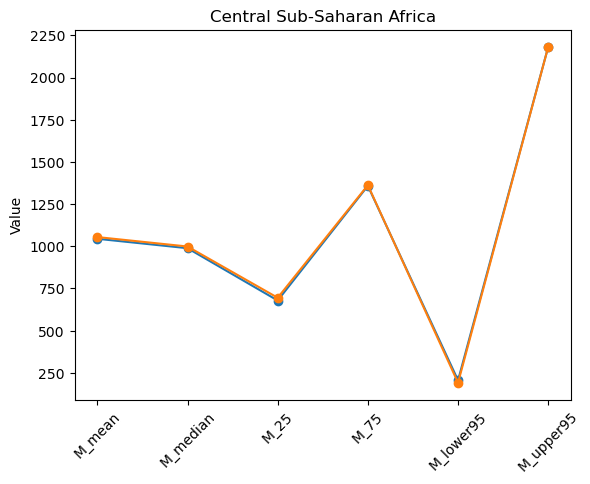

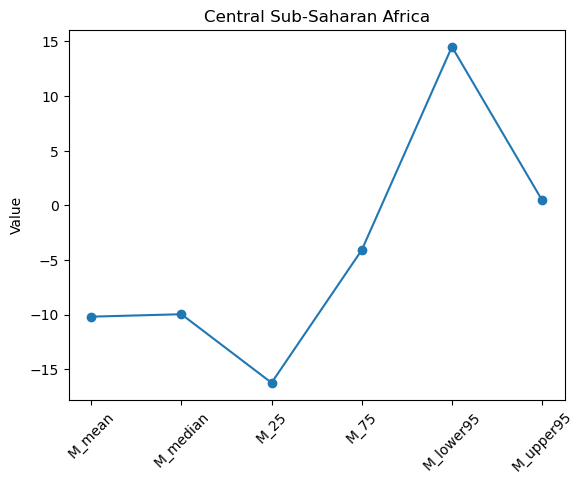

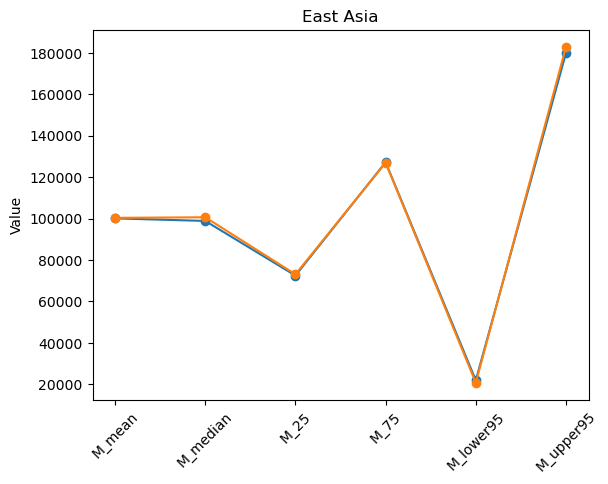

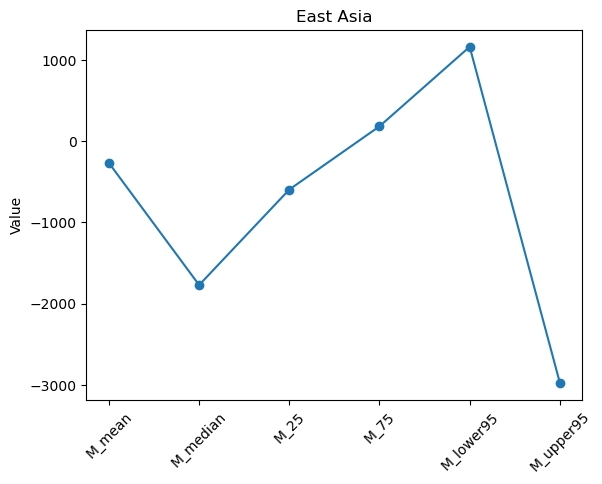

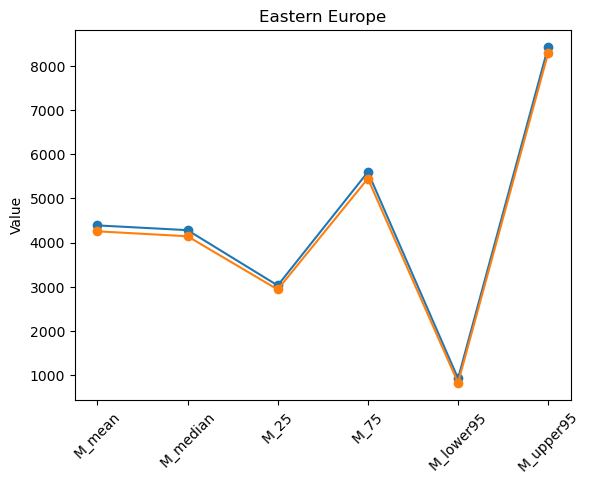

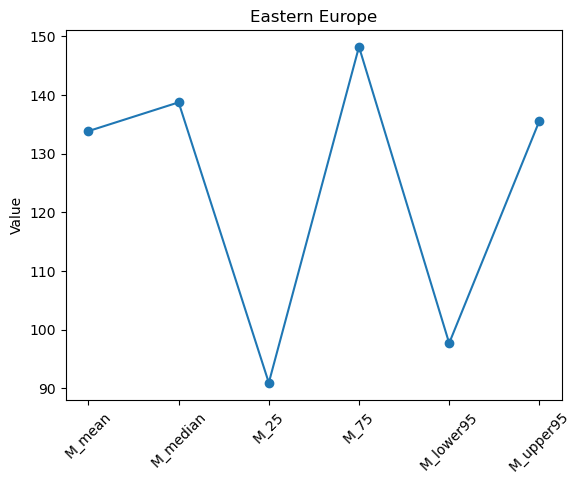

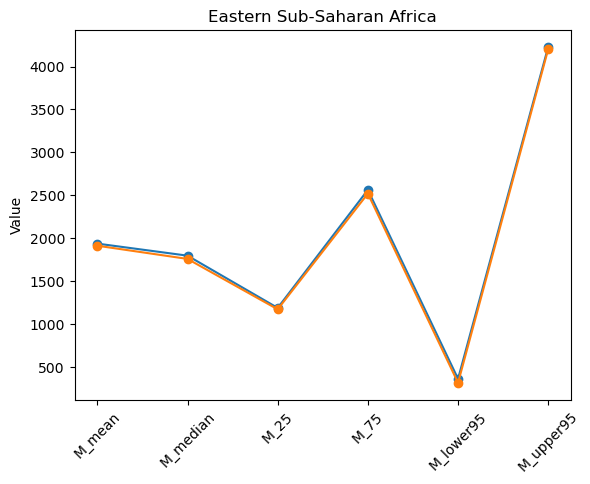

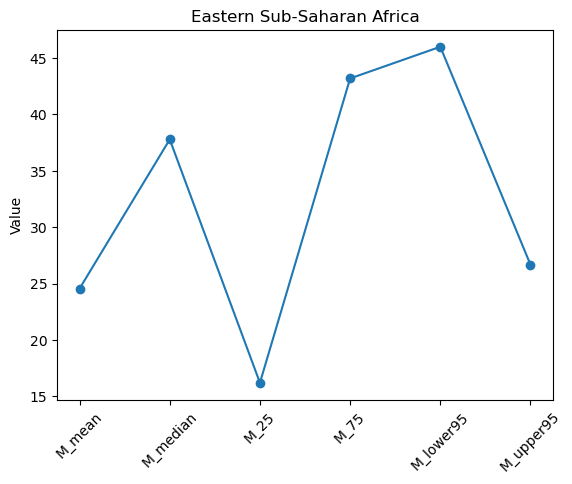

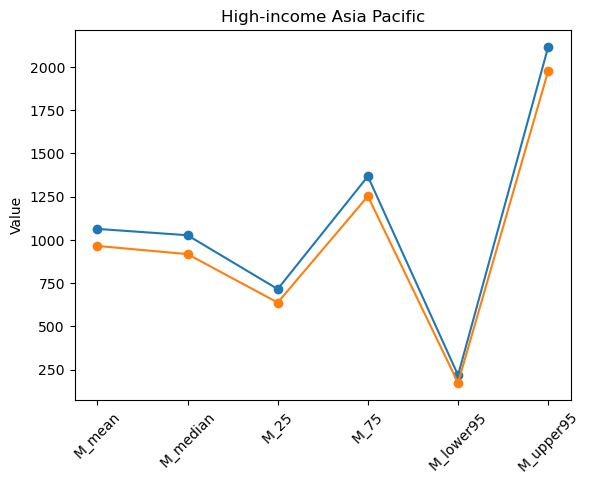

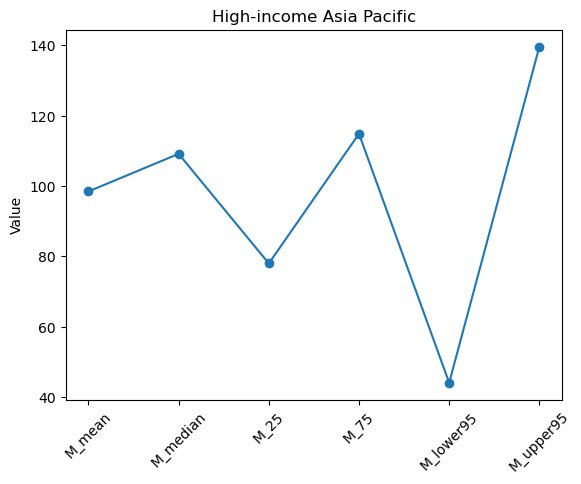

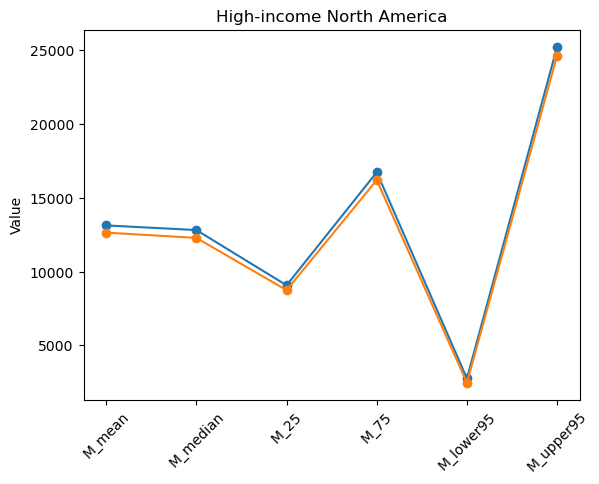

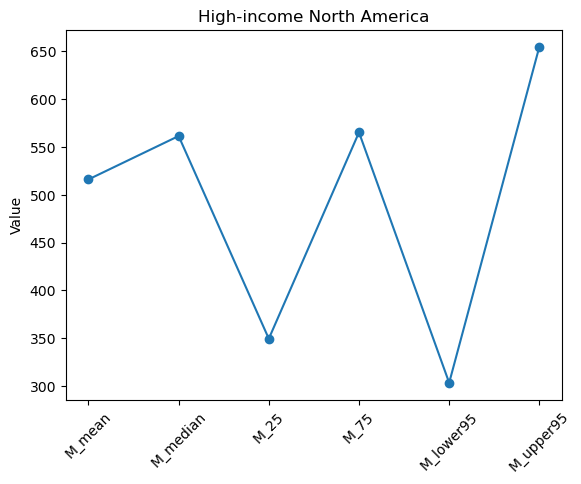

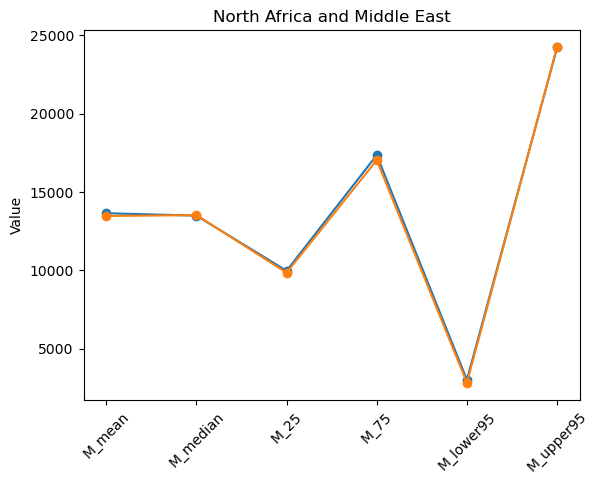

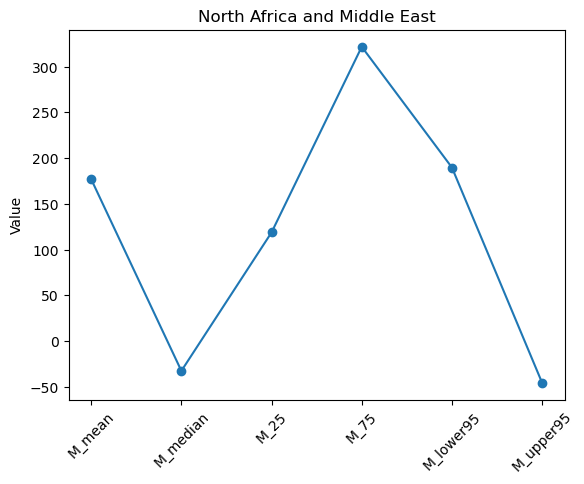

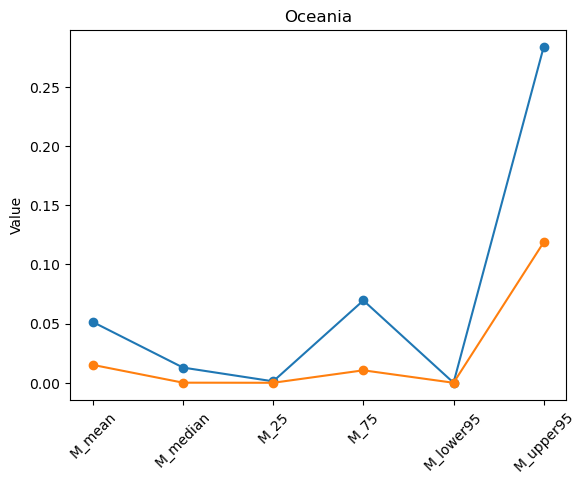

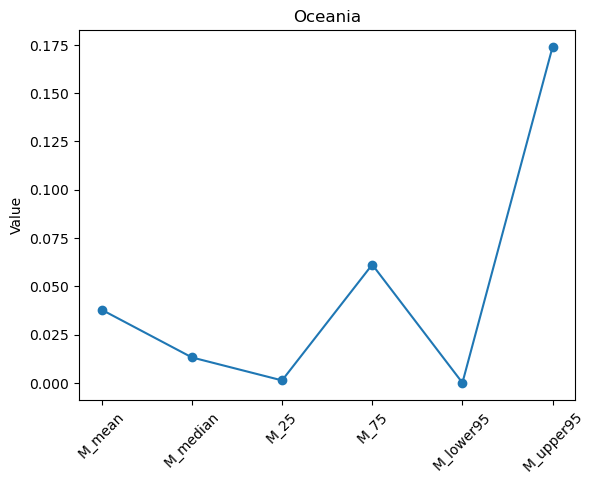

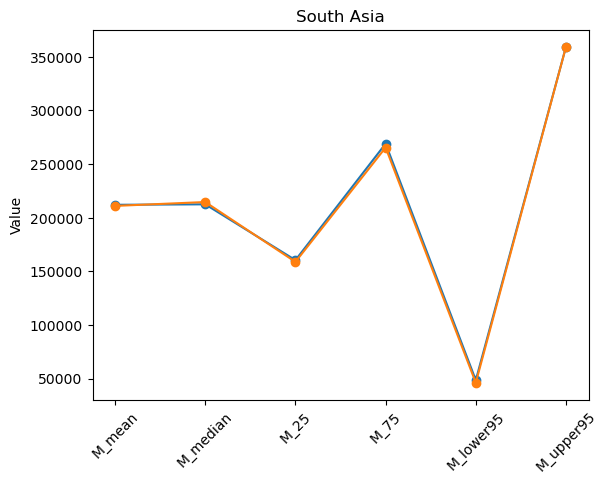

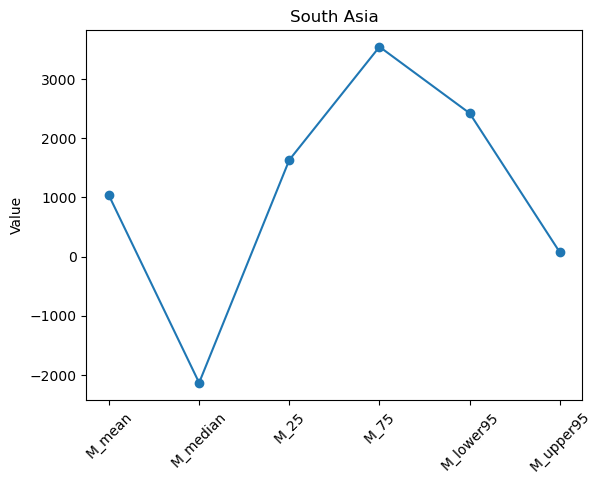

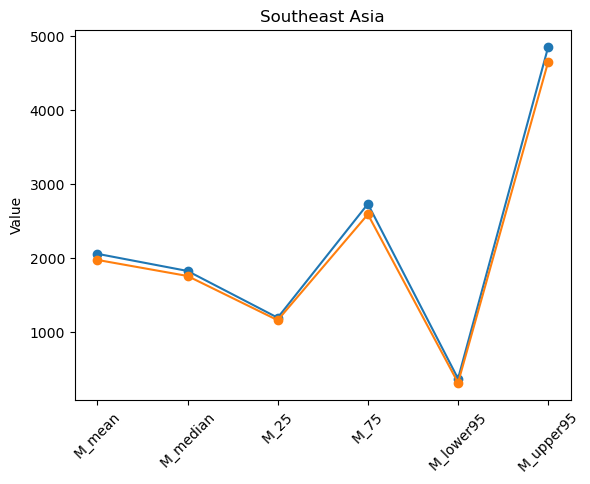

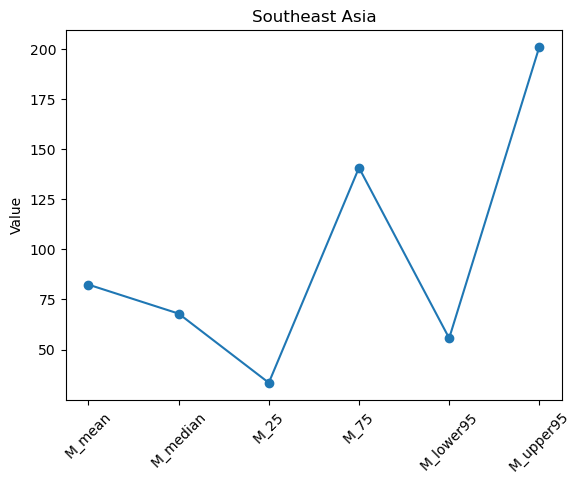

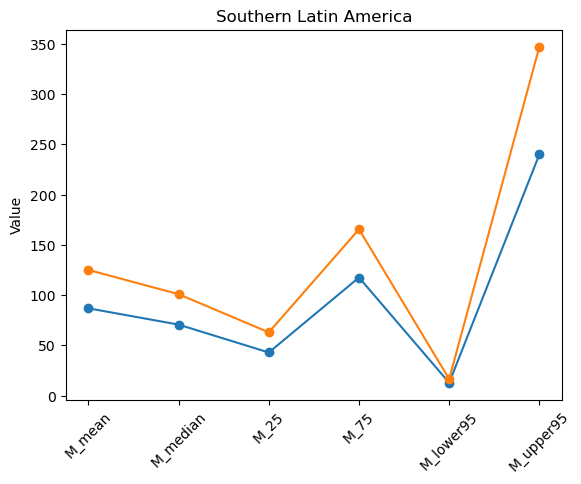

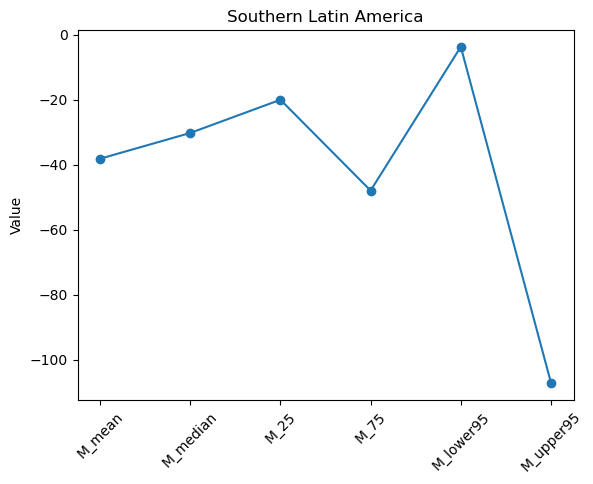

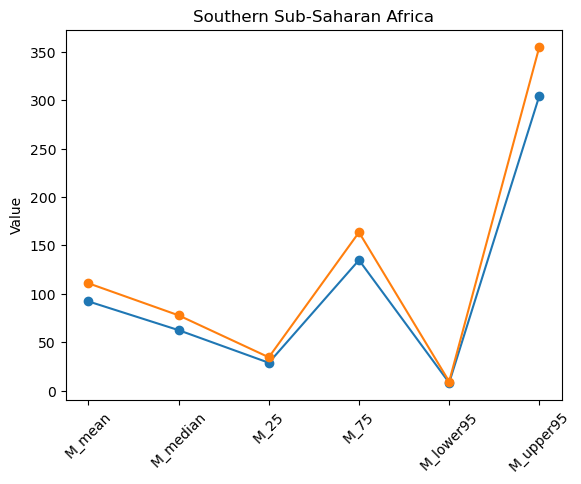

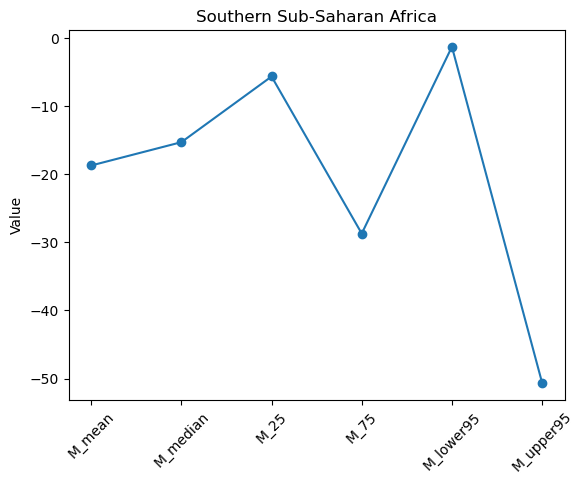

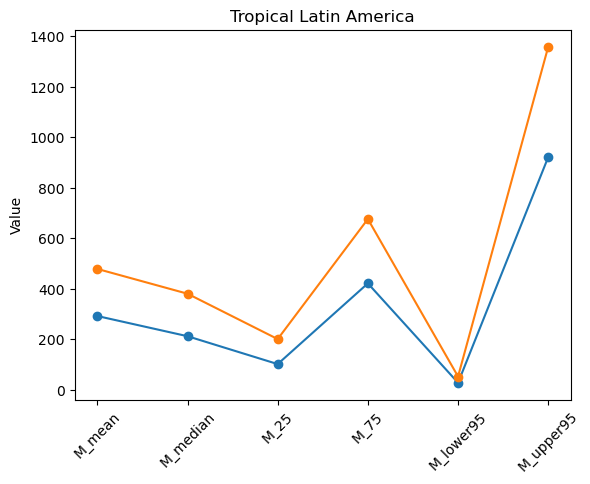

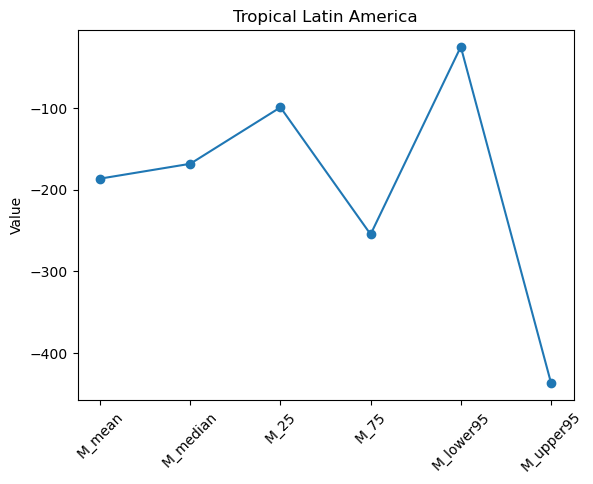

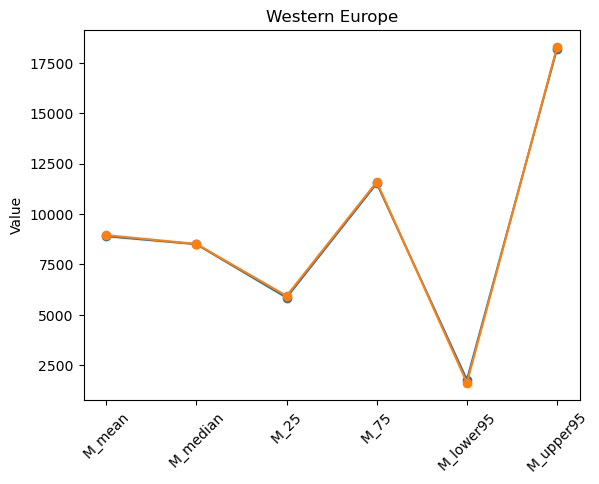

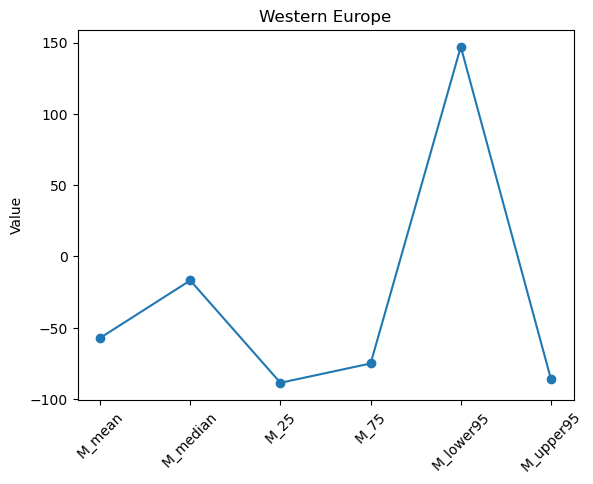

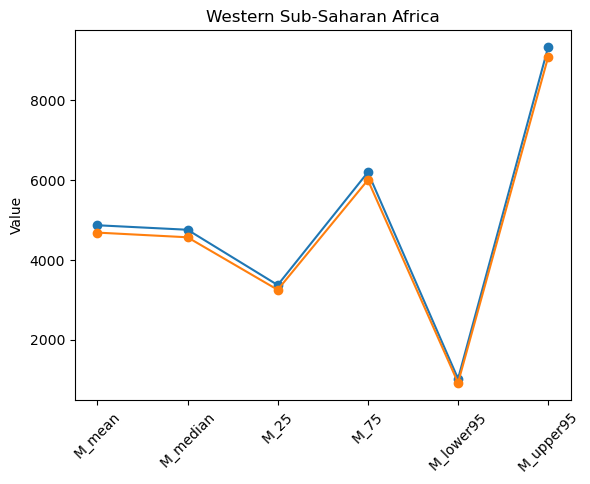

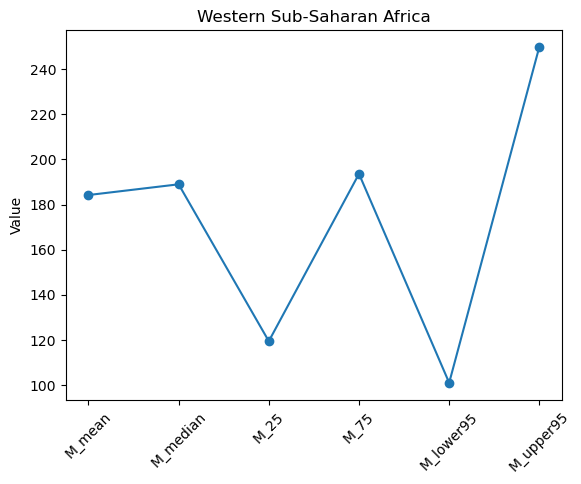

In [35]:
da1_dec = da1.sel(year=slice("2073", "2084")).mean(dim=("year", "ensemble"))
da2_dec = da2.sel(year=slice("2073", "2084")).mean(dim=("year", "ensemble"))
da_dec = da.sel(year=slice("2073", "2084")).mean(dim=("year", "ensemble"))

for region in da.region:
    plt.figure()
    data_da1 = da1_dec.sel(region=region).to_dict()["data_vars"]
    names = list(data_da1.keys())
    values_da1 = [data_da1[v]["data"] for v in names]
    data_da2 = da2_dec.sel(region=region).to_dict()["data_vars"]
    names = list(data_da2.keys())
    values_da2 = [data_da2[v]["data"] for v in names]
    data_da = da_dec.sel(region=region).to_dict()["data_vars"]
    names = list(data_da.keys())
    values_da = [data_da[v]["data"] for v in names]

    plt.plot(names, values_da1, "o-")
    plt.plot(names, values_da2, "o-")

    plt.ylabel("Value")
    plt.title(f"{region.data}")
    plt.xticks(rotation=45)
    plt.show()

    plt.figure()
    plt.plot(names, values_da, "o-")

    plt.ylabel("Value")
    plt.title(f"{region.data}")
    plt.xticks(rotation=45)
    plt.show()
